In [26]:
from enum import unique

import pandas as pd
import warnings

warnings.filterwarnings('ignore')

In [27]:
train_df = pd.read_csv("./inputs/train.csv").set_index("id")
target = train_df["Listening_Time_minutes"]
train_df

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
id,,,,,,,,,,,
0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...,...,...
749995,Learning Lab,Episode 25,75.66,Education,69.36,Saturday,Morning,NaN,0.0,Negative,56.87058
749996,Business Briefs,Episode 21,75.75,Business,35.21,Saturday,Night,NaN,2.0,Neutral,45.46242
749997,Lifestyle Lounge,Episode 51,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000


In [28]:
# Filtering the Categorical and Non-Categorical columns
categories = train_df.select_dtypes(include=object).columns
non_categories = train_df.select_dtypes(include=["number"]).columns[:-1]

display(categories)
display(non_categories)

Index(['Podcast_Name', 'Episode_Title', 'Genre', 'Publication_Day',
       'Publication_Time', 'Episode_Sentiment'],
      dtype='object')

Index(['Episode_Length_minutes', 'Host_Popularity_percentage',
       'Guest_Popularity_percentage', 'Number_of_Ads'],
      dtype='object')

In [29]:
%store non_categories
%store categories

Stored 'non_categories' (Index)
Stored 'categories' (Index)


In [30]:
# Missing data
train_df.isnull().sum()

Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

In [31]:
# Create a copy of train_df
train_df_copy = train_df.copy()

## Handling Missing Data
From the table above, there are two features `Episode_Length_minutes` and `Guest_Popularity_percentage` that have a significant number of missing values.
So I thought instead of using the normal methods like imputing or filling in the missing values based on the mean or KNN of the other data around it, what if we use a model to predict them?

In [32]:
# First, split the dataset into missing values for ELm (Episode_Listening_minutes) and non-missing data
train_df_copy["Number_of_Ads"] = train_df_copy["Number_of_Ads"].fillna(0)

# Data that does not have any missing values
non_missing = train_df_copy.dropna(subset=["Episode_Length_minutes","Guest_Popularity_percentage"])

# Data that has all missing ELm values
missing_ELm = train_df_copy[train_df_copy["Episode_Length_minutes"].isnull()]

# Data that has all missing GPl values
missing_GPl = train_df_copy[train_df_copy["Guest_Popularity_percentage"].isnull()]

In [33]:
# Encode the categorical features
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in categories:
    non_missing.loc[:, column] = le.fit_transform(non_missing[column])
    missing_ELm.loc[:, column] = le.fit_transform(missing_ELm[column])
    missing_GPl.loc[:, column] = le.fit_transform(missing_GPl[column])

non_missing

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
id,,,,,,,,,,,
1,24,19,119.80,1,66.95,2,0,75.95,2.0,0,88.01241
2,40,8,73.90,2,69.97,5,1,8.97,0.0,0,44.92531
3,10,40,67.17,8,57.22,1,2,78.70,2.0,2,46.27824
4,31,85,110.51,3,80.07,1,0,58.68,3.0,1,75.61031
6,6,42,69.83,9,35.82,3,3,39.02,0.0,1,64.75024
...,...,...,...,...,...,...,...,...,...,...,...
749992,12,73,48.67,4,88.62,6,1,25.65,3.0,2,42.08465
749993,41,82,23.52,4,38.14,5,1,86.17,0.0,1,19.71374
749997,28,47,30.98,4,78.58,4,2,84.89,0.0,0,15.26000


In [34]:
# Encode train_df_copy categorical features
for column in categories:
    train_df_copy[column] = le.fit_transform(train_df_copy[column])

In [35]:
# # Scaling the non-categorical features
# from sklearn.preprocessing import StandardScaler
#
# scaler = StandardScaler()
#
# for dataset in [non_missing, missing_ELm, missing_GPl]:
#     dataset[dataset.select_dtypes(include=["number"]).columns[:-1]] = scaler.fit_transform(dataset[dataset.select_dtypes(include=["number"]).columns[:-1]])
#
# missing_GPl

In [36]:
# Splitting the data once again
# Data that has all missing ELm values and also some missing GPl values
missing_elm = missing_ELm[missing_ELm["Guest_Popularity_percentage"].notnull()]

# Data that has both missing ELm and GPl values from missing_ELm
missing_both_elm = missing_ELm[missing_ELm["Guest_Popularity_percentage"].isnull()]

# Data that has all missing GPl values and also some missing ELm values
missing_gpl = missing_GPl[missing_GPl["Episode_Length_minutes"].notnull()]

# Data that has both missing GPl and ELm values from missing_GPl
missing_both_gpl = missing_GPl[missing_GPl["Episode_Length_minutes"].isnull()]

In [37]:
# Predictive imputing on ELm
from sklearn.ensemble import RandomForestRegressor

# Step 1: Train model on known data
X_elm_train = non_missing.drop(columns=["Episode_Length_minutes"])
y_elm_train = non_missing["Episode_Length_minutes"]

elm_model = RandomForestRegressor()
elm_model.fit(X_elm_train, y_elm_train)

# Step 2: Predict missing ELm where GPl is available
X_elm_predict = missing_elm.drop(columns=["Episode_Length_minutes"])
elm_preds = elm_model.predict(X_elm_predict)

# Step 3: Fill predictions
train_df.loc[missing_elm.index, "Episode_Length_minutes"] = elm_preds

In [38]:
# Predictive imputing on GPl
# Step 1: Update non_missing to include rows with newly filled ELm
non_missing_gpl = train_df_copy.dropna(subset=["Guest_Popularity_percentage", "Episode_Length_minutes"])

# Step 2: Train model to predict GPl
X_gpl_train = non_missing_gpl.drop(columns=["Guest_Popularity_percentage"])
y_gpl_train = non_missing_gpl["Guest_Popularity_percentage"]

gpl_model = RandomForestRegressor()
gpl_model.fit(X_gpl_train, y_gpl_train)

# Step 3: Predict GPl for rows with missing GPl and known ELm
X_gpl_predict = missing_gpl.drop(columns=["Guest_Popularity_percentage"])
gpl_preds = gpl_model.predict(X_gpl_predict)

# Step 4: Fill predictions
train_df.loc[missing_gpl.index, "Guest_Popularity_percentage"] = gpl_preds

In [39]:
# Handling missing_both_elm and missing_both_gpl
# Fill Episode_Length_minutes in missing_both_elm
X_both_elm = missing_both_elm.drop(columns=["Episode_Length_minutes"])
elm_preds_both = elm_model.predict(X_both_elm)
train_df.loc[missing_both_elm.index, "Episode_Length_minutes"] = elm_preds_both

# Fill Guest_Popularity_percentage in missing_both_gpl
X_both_gpl = missing_both_gpl.drop(columns=["Guest_Popularity_percentage"])
gpl_preds_both = gpl_model.predict(X_both_gpl)
train_df.loc[missing_both_gpl.index, "Guest_Popularity_percentage"] = gpl_preds_both

In [40]:
train_df["Number_of_Ads"] = train_df["Number_of_Ads"].fillna(0)

From here, the cell below are just me trying to get an understanding of the data

In [41]:
train_df

,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
id,,,,,,,,,,,
0,Mystery Matters,Episode 98,46.5033,True Crime,74.81,Thursday,Night,56.8075,0.0,Positive,31.41998
1,Joke Junction,Episode 26,119.8000,Comedy,66.95,Saturday,Afternoon,75.9500,2.0,Negative,88.01241
2,Study Sessions,Episode 16,73.9000,Education,69.97,Tuesday,Evening,8.9700,0.0,Negative,44.92531
3,Digital Digest,Episode 45,67.1700,Technology,57.22,Monday,Morning,78.7000,2.0,Positive,46.27824
4,Mind & Body,Episode 86,110.5100,Health,80.07,Monday,Afternoon,58.6800,3.0,Neutral,75.61031
...,...,...,...,...,...,...,...,...,...,...,...
749995,Learning Lab,Episode 25,75.6600,Education,69.36,Saturday,Morning,55.0653,0.0,Negative,56.87058
749996,Business Briefs,Episode 21,75.7500,Business,35.21,Saturday,Night,49.5326,2.0,Neutral,45.46242
749997,Lifestyle Lounge,Episode 51,30.9800,Lifestyle,78.58,Thursday,Morning,84.8900,0.0,Negative,15.26000


In [42]:
arr = []
train_df = train_df.copy()  # To not make changes to the existing dataset
train_df_no_na = train_df.dropna()

train_df_no_na.groupby(["Publication_Day"])["Guest_Popularity_percentage"].mean().reset_index()

,Publication_Day,Guest_Popularity_percentage
0,Friday,52.512128
1,Monday,51.742048
2,Saturday,52.223814
3,Sunday,52.098928
4,Thursday,52.067654
5,Tuesday,52.204092
6,Wednesday,52.354451


In [43]:
train_df_no_na.groupby(["Publication_Day"])["Host_Popularity_percentage"].mean().reset_index()

,Publication_Day,Host_Popularity_percentage
0,Friday,60.133379
1,Monday,59.748571
2,Saturday,60.355934
3,Sunday,59.492192
4,Thursday,59.567553
5,Tuesday,59.809638
6,Wednesday,59.948857


In [44]:
train_df_no_na.groupby(["Publication_Time"])["Guest_Popularity_percentage"].mean().reset_index()

,Publication_Time,Guest_Popularity_percentage
0,Afternoon,52.472745
1,Evening,52.077675
2,Morning,52.118100
3,Night,52.027694


In [45]:
train_df_no_na.groupby(["Publication_Time"])["Host_Popularity_percentage"].mean().reset_index()

,Publication_Time,Host_Popularity_percentage
0,Afternoon,59.746282
1,Evening,60.010462
2,Morning,59.853105
3,Night,59.819883


In [46]:
train_df.groupby(["Publication_Day", "Publication_Time"])["Host_Popularity_percentage"].mean().reset_index()

,Publication_Day,Publication_Time,Host_Popularity_percentage
0,Friday,Afternoon,60.055941
1,Friday,Evening,60.270606
2,Friday,Morning,60.039549
3,Friday,Night,60.156807
4,Monday,Afternoon,59.714208
5,Monday,Evening,59.909541
6,Monday,Morning,59.652435
7,Monday,Night,59.707558
8,Saturday,Afternoon,60.152333
9,Saturday,Evening,60.429721


In [47]:
train_df.groupby(["Number_of_Ads"])["Listening_Time_minutes"].mean().reset_index()

,Number_of_Ads,Listening_Time_minutes
0,0.00,49.072989
1,1.00,47.273397
2,2.00,43.214216
3,3.00,40.237940
4,12.00,6.490000
5,53.37,50.448920
6,53.42,50.448920
7,103.00,103.126860
8,103.25,103.126860
9,103.75,103.126860


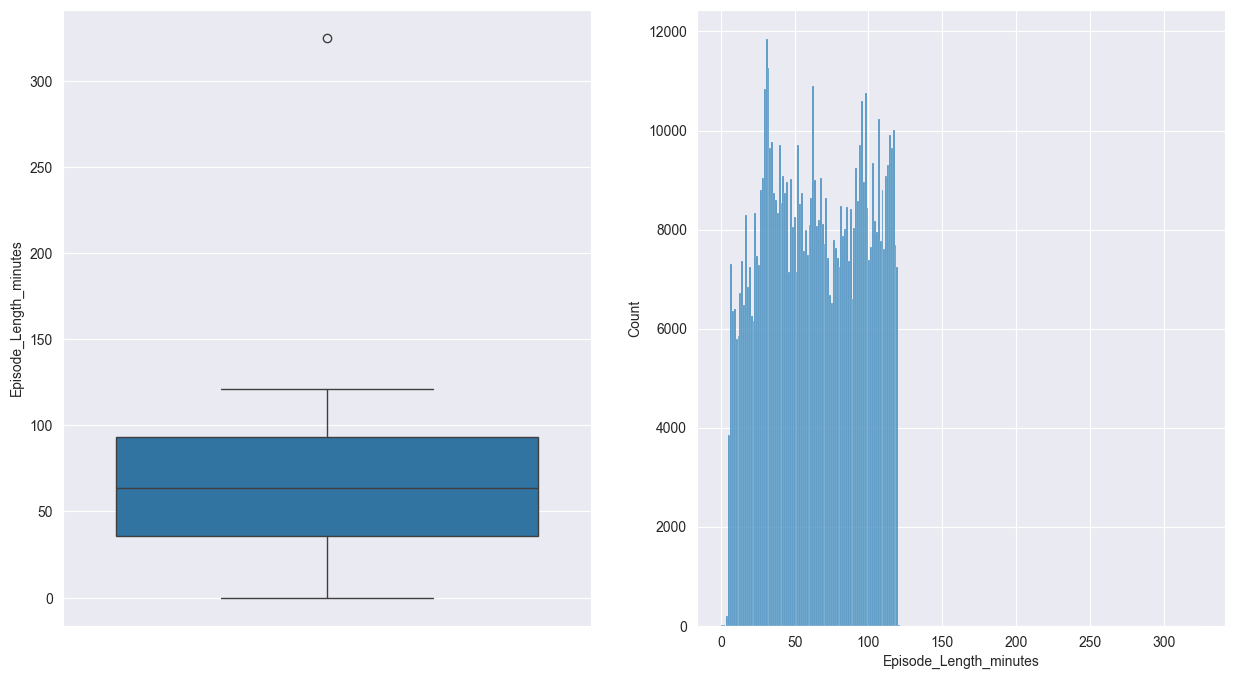

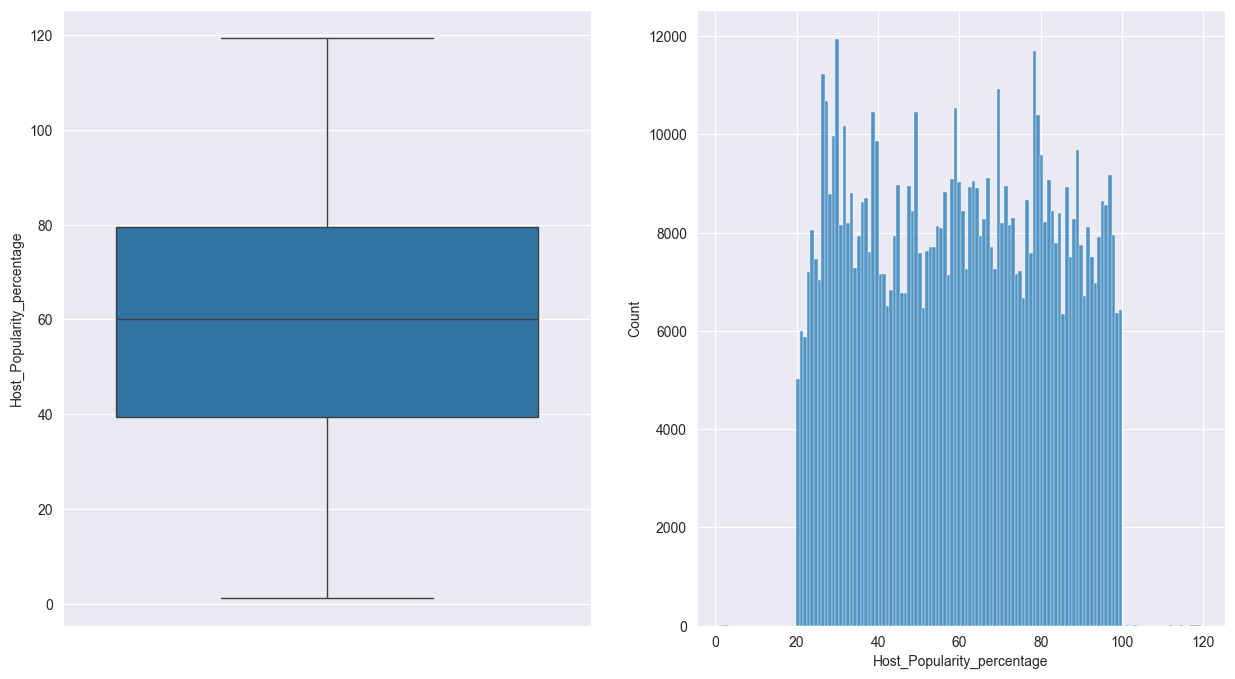

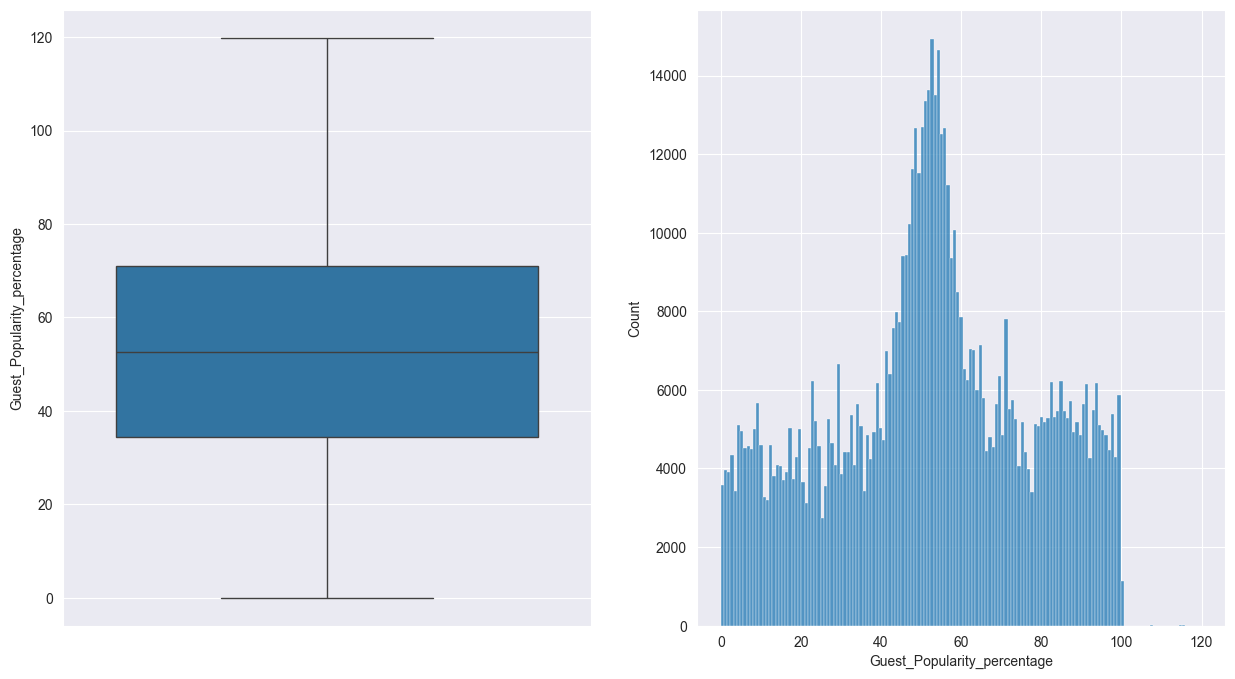

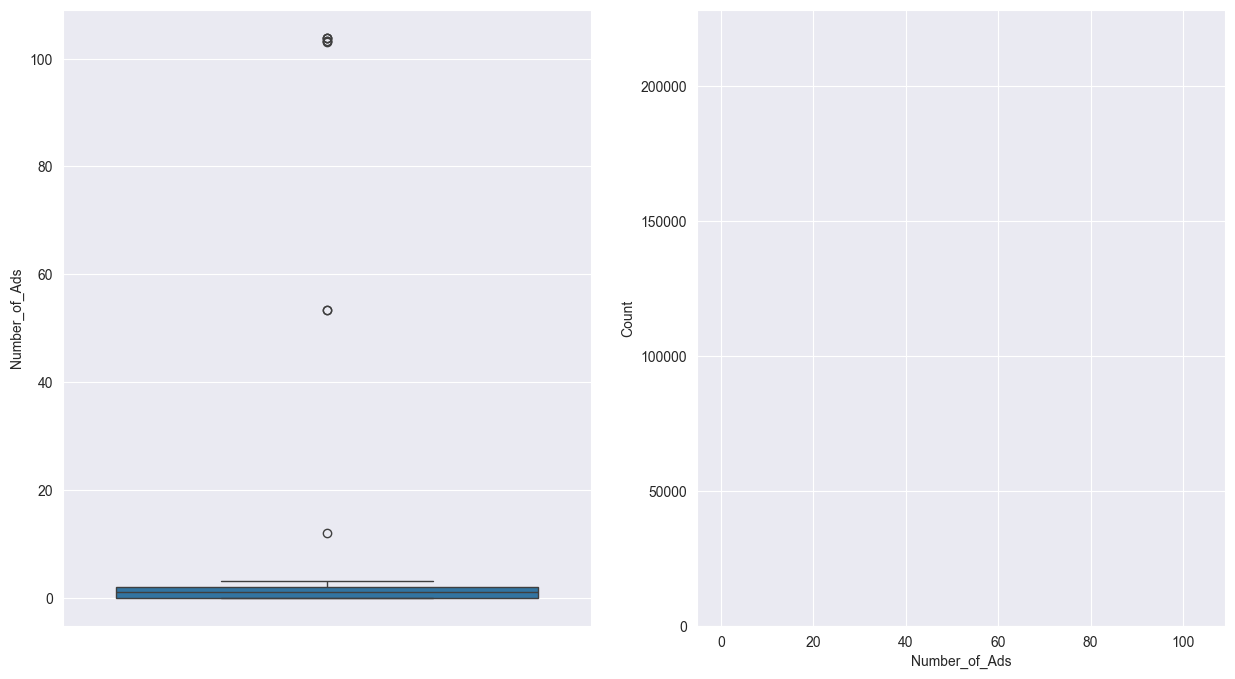

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

for column in non_categories:
    plt.figure(figsize=(15, 8))
    plt.subplot(1, 2, 1)
    sns.boxplot(data=train_df, y=column, )
    plt.subplot(1, 2, 2)
    sns.histplot(data=train_df, x=column, kde=False)
    plt.show()

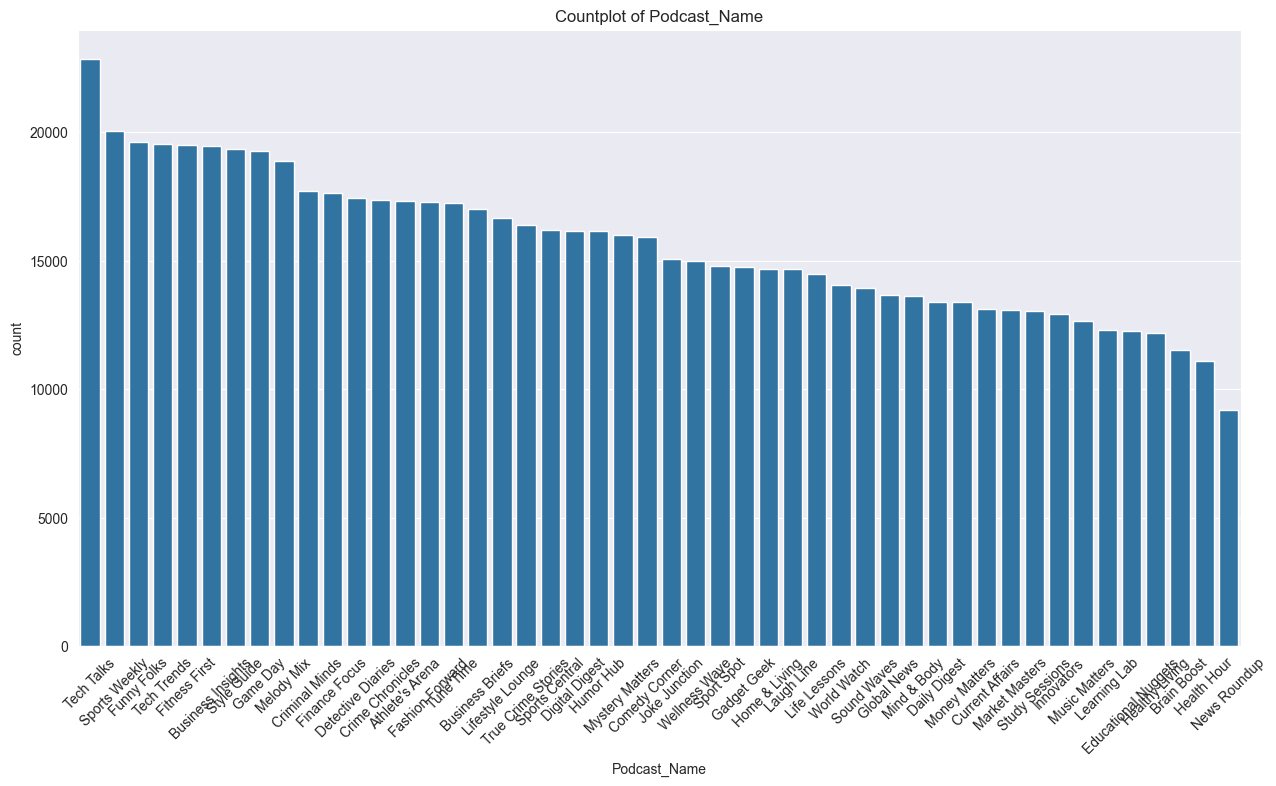

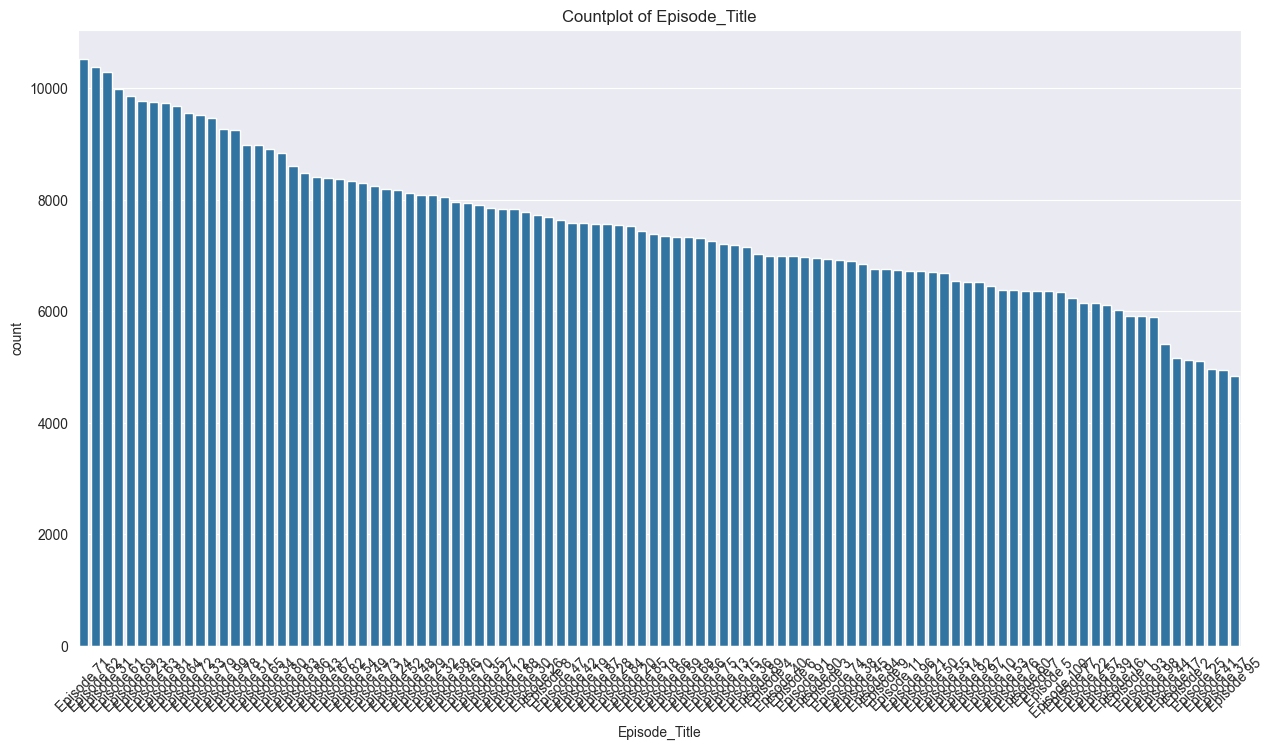

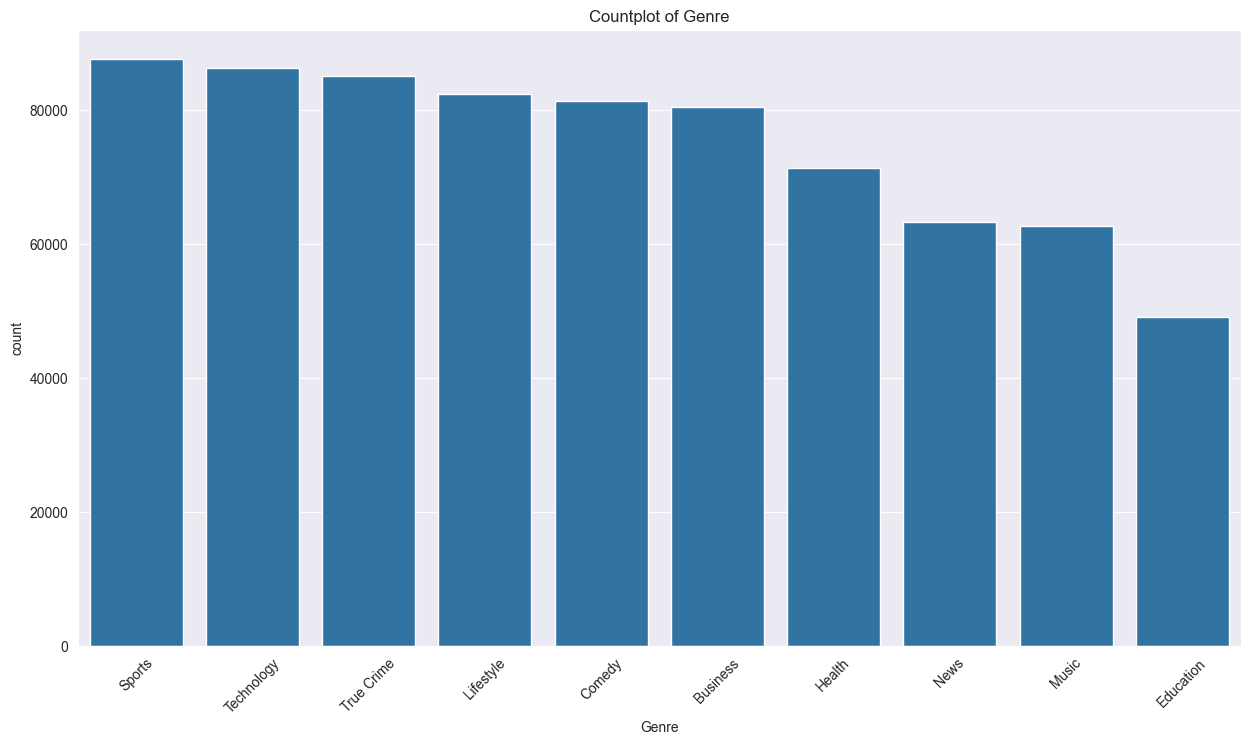

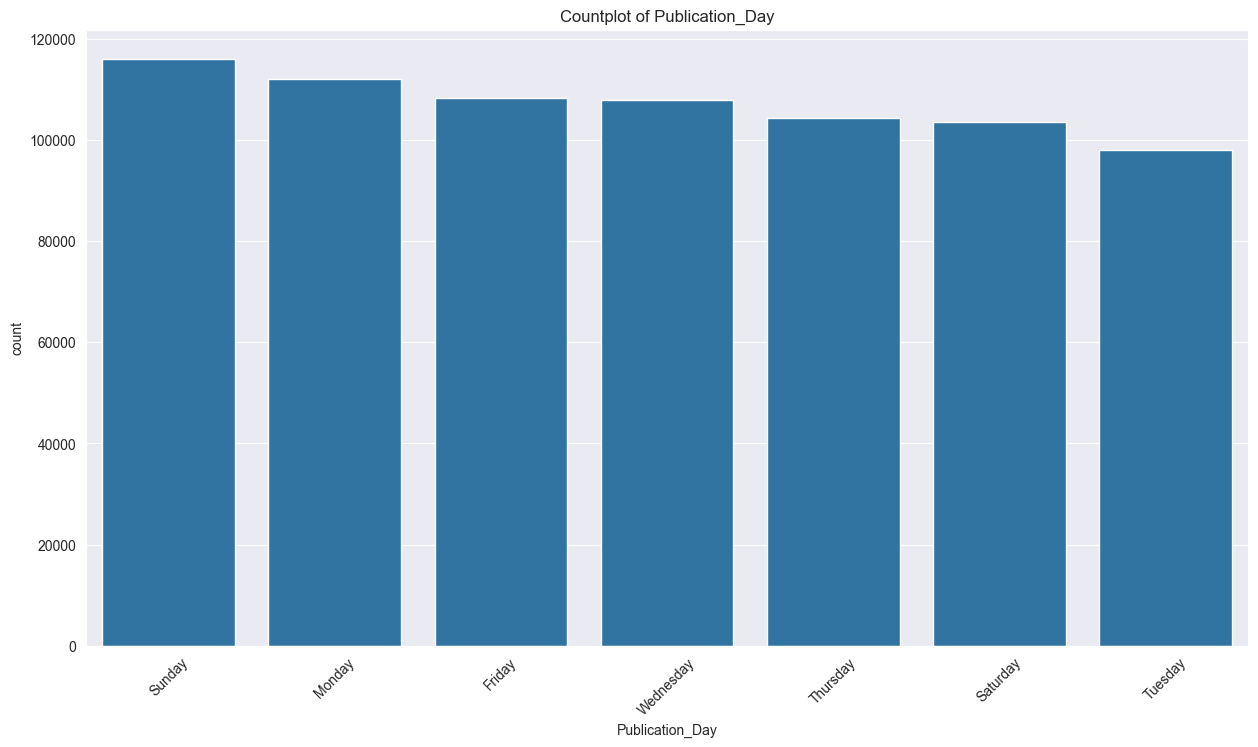

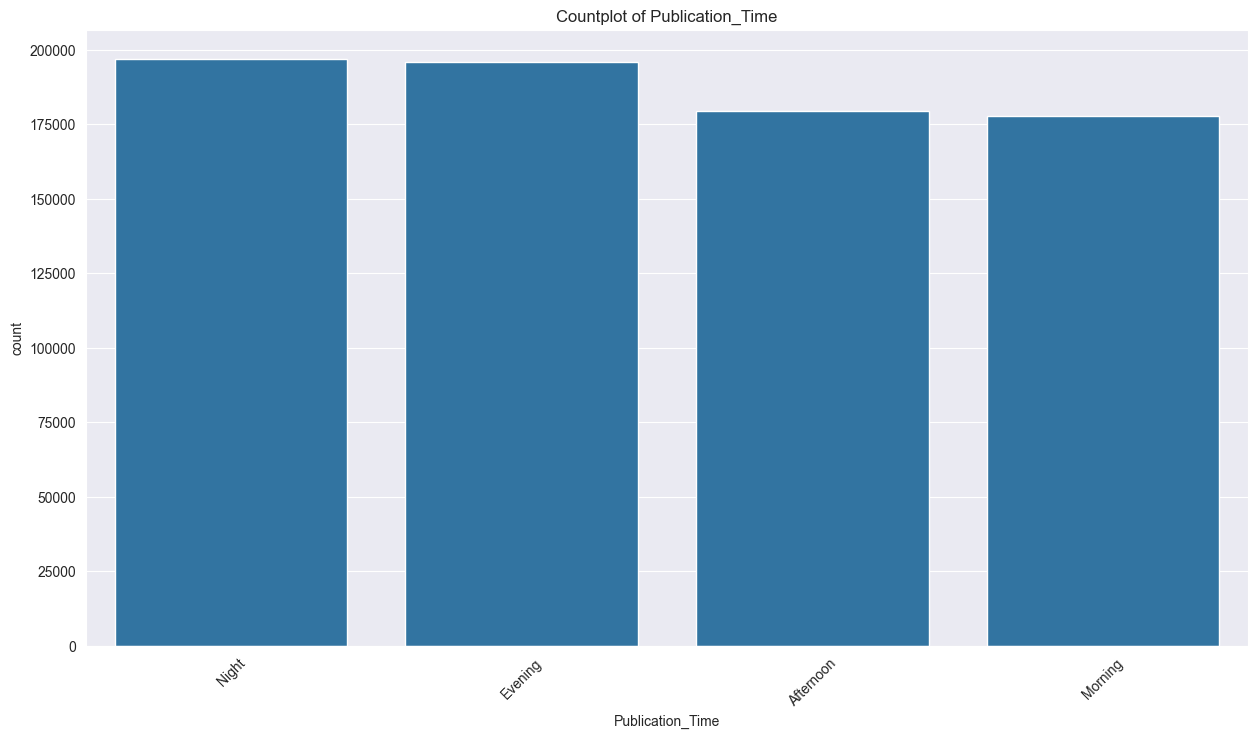

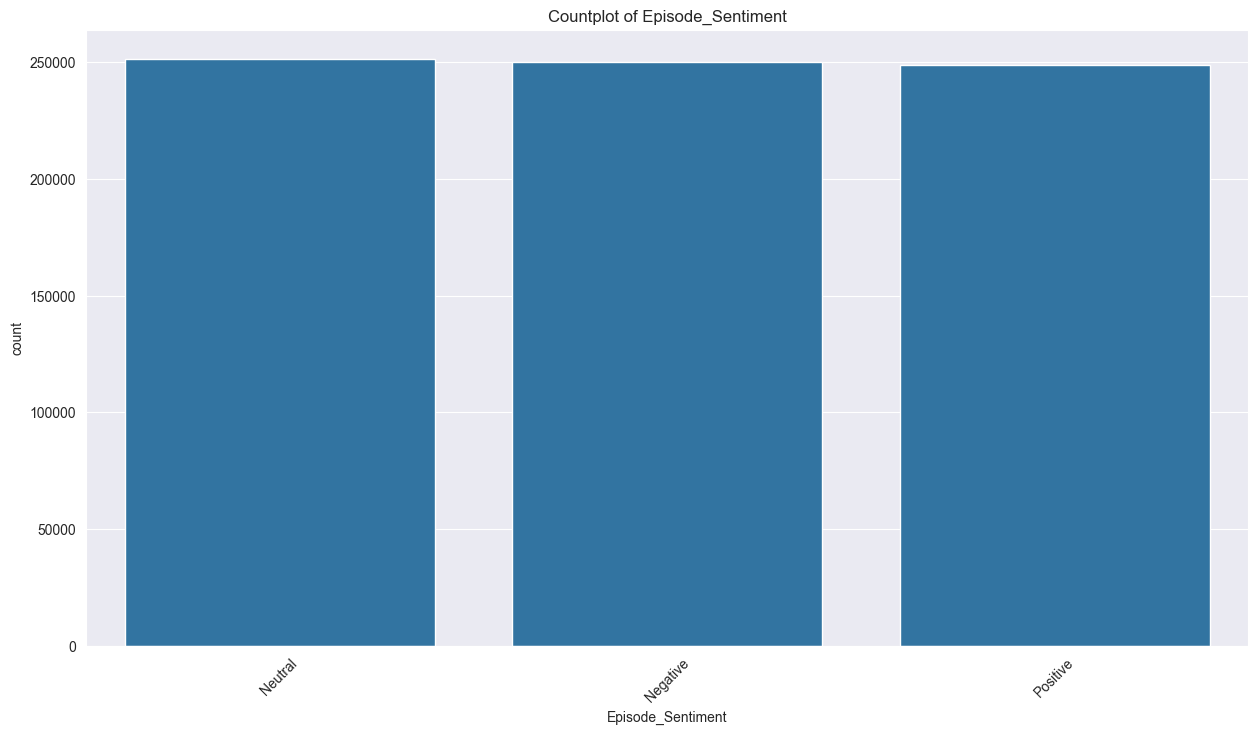

In [49]:
for column in categories:
    plt.figure(figsize=(15, 8))
    sns.countplot(data=train_df, x=column, order=train_df[column].value_counts().index)
    plt.title(f'Countplot of {column}')
    plt.xticks(rotation=45)
    plt.show()

In [50]:
%store train_df

Stored 'train_df' (DataFrame)


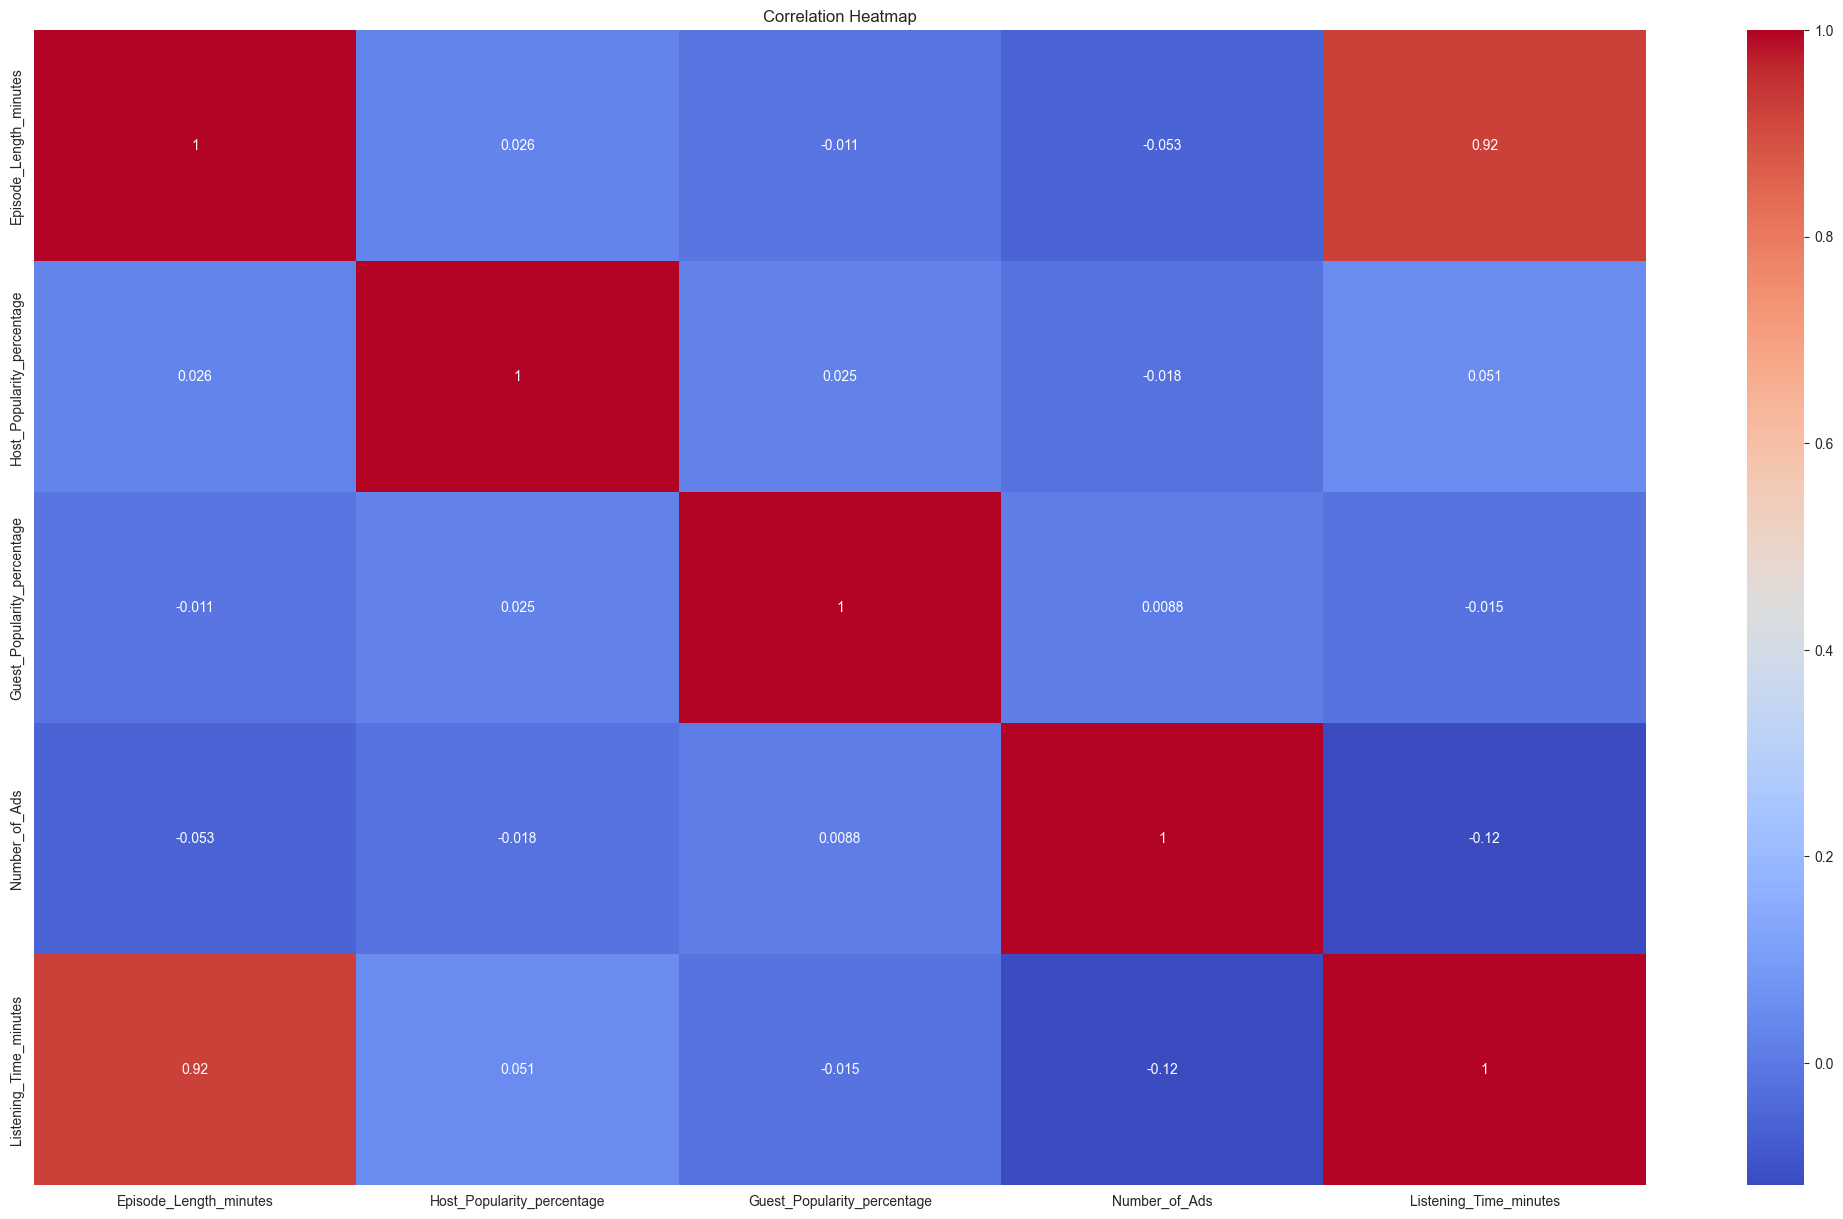

In [51]:
numeric_df = train_df.select_dtypes(include=["number"])
plt.figure(figsize=(26, 15))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Feature - Target Correlation:

Episode_Length_minutes         0.922572
Number_of_Ads                 -0.118336
Host_Popularity_percentage     0.050870
Guest_Popularity_percentage   -0.014826
Name: Listening_Time_minutes, dtype: float64


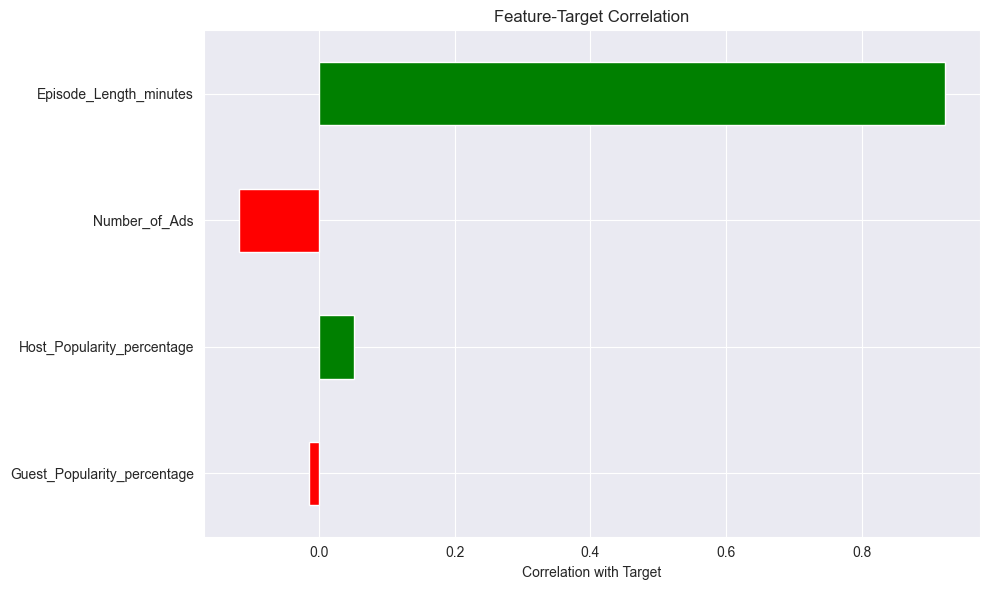

In [53]:
target_col = "Listening_Time_minutes"

# 2. Drop rows with missing target values
numeric_df = numeric_df.dropna(subset=[target_col])

# 3. Calculate correlation of all features with the target
correlation_with_target = numeric_df.corr()[target_col].drop(target_col)

# 4. Sort by absolute correlation value (strongest at top)
sorted_corr = correlation_with_target.reindex(correlation_with_target.abs().sort_values(ascending=False).index)

# 5. Display the results
print("Feature - Target Correlation:\n")
print(sorted_corr)

# 6. Optional: Visualize as horizontal bar plot
plt.figure(figsize=(10, 6))
sorted_corr.plot(kind='barh', color=sorted_corr.apply(lambda x: 'green' if x > 0 else 'red'))
plt.xlabel('Correlation with Target')
plt.title('Feature-Target Correlation')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()